In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import unicodedata

from folium.plugins import HeatMap

sns.set_style("whitegrid")

In [2]:
def normalizar(texto):
    
    texto = str(texto)
    
    texto = unicodedata.normalize(
        'NFKD',
        texto
    )
    
    texto = (
        texto
        .encode('ASCII', 'ignore')
        .decode('utf-8')
    )
    
    return texto.upper().strip()

In [3]:
df_tipos = pd.read_csv(
    "resultado_tipos_municipio.csv"
)

df_sazonalidade = pd.read_csv(
    "resultado_sazonalidade.csv"
)

df_correlacao = pd.read_csv(
    "resultado_correlacao.csv"
)

gdf_municipios = gpd.read_file(
    "municipios-go.geojson"
)

gdf_focos = gpd.read_file(
    "focos-queimadas-go.geojson"
)

In [4]:
df_tipos["municipio"] = (
    df_tipos["municipio"]
    .apply(normalizar)
)

df_correlacao["name"] = (
    df_correlacao["name"]
    .apply(normalizar)
)

gdf_municipios["name"] = (
    gdf_municipios["name"]
    .apply(normalizar)
)

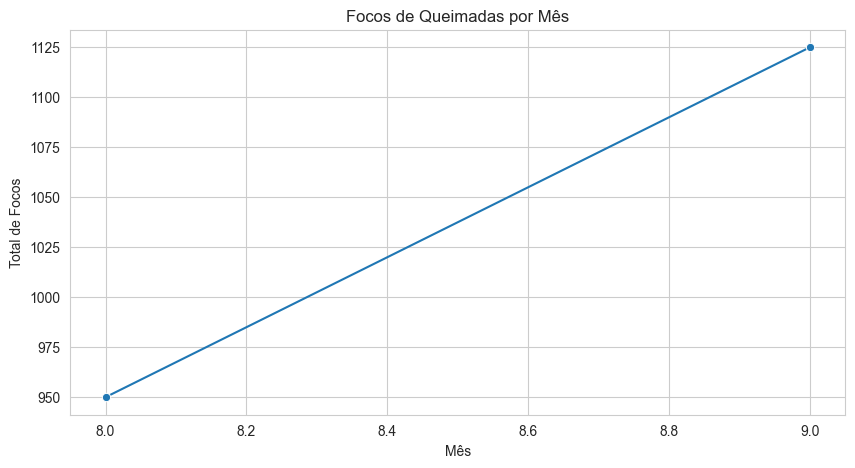

In [5]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_sazonalidade,
    x="mes",
    y="total_focos",
    marker="o"
)

plt.title(
    "Focos de Queimadas por Mês"
)

plt.xlabel("Mês")

plt.ylabel("Total de Focos")

plt.show()

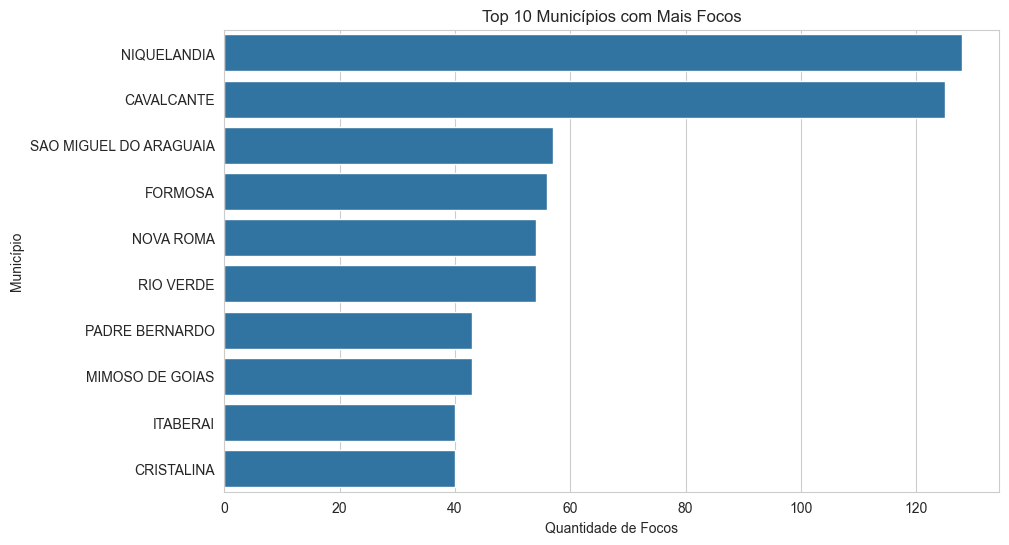

In [6]:
top10 = (
    df_tipos
    .sort_values(
        "quantidade_focos",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="quantidade_focos",
    y="municipio"
)

plt.title(
    "Top 10 Municípios com Mais Focos"
)

plt.xlabel(
    "Quantidade de Focos"
)

plt.ylabel("Município")

plt.show()

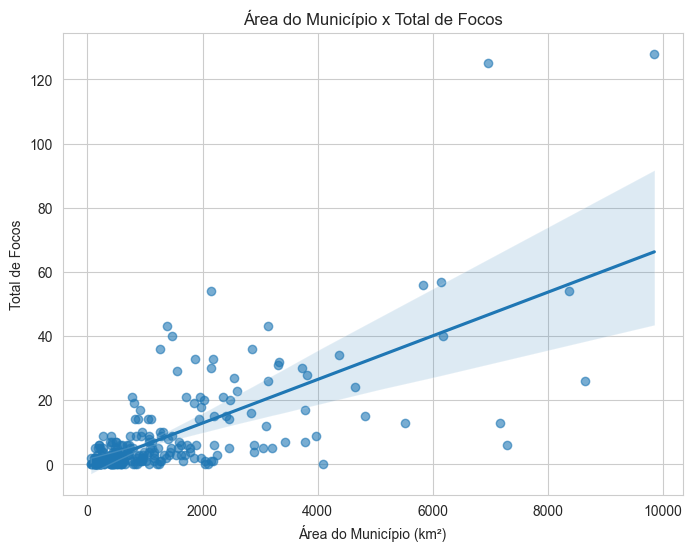

In [7]:
# Remover valores inválidos
df_corr = df_correlacao[
    df_correlacao["area_mun_km2"] > 0
].copy()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_corr,
    x="area_mun_km2",
    y="total_focos",
    scatter_kws={
        "alpha":0.6
    }
)

plt.title(
    "Área do Município x Total de Focos"
)

plt.xlabel(
    "Área do Município (km²)"
)

plt.ylabel(
    "Total de Focos"
)

plt.show()

In [8]:
gdf_mapa = gdf_municipios.merge(
    df_tipos,
    left_on="name",
    right_on="municipio",
    how="left"
)

gdf_mapa[
    "quantidade_focos"
] = (
    gdf_mapa[
        "quantidade_focos"
    ]
    .fillna(0)
)

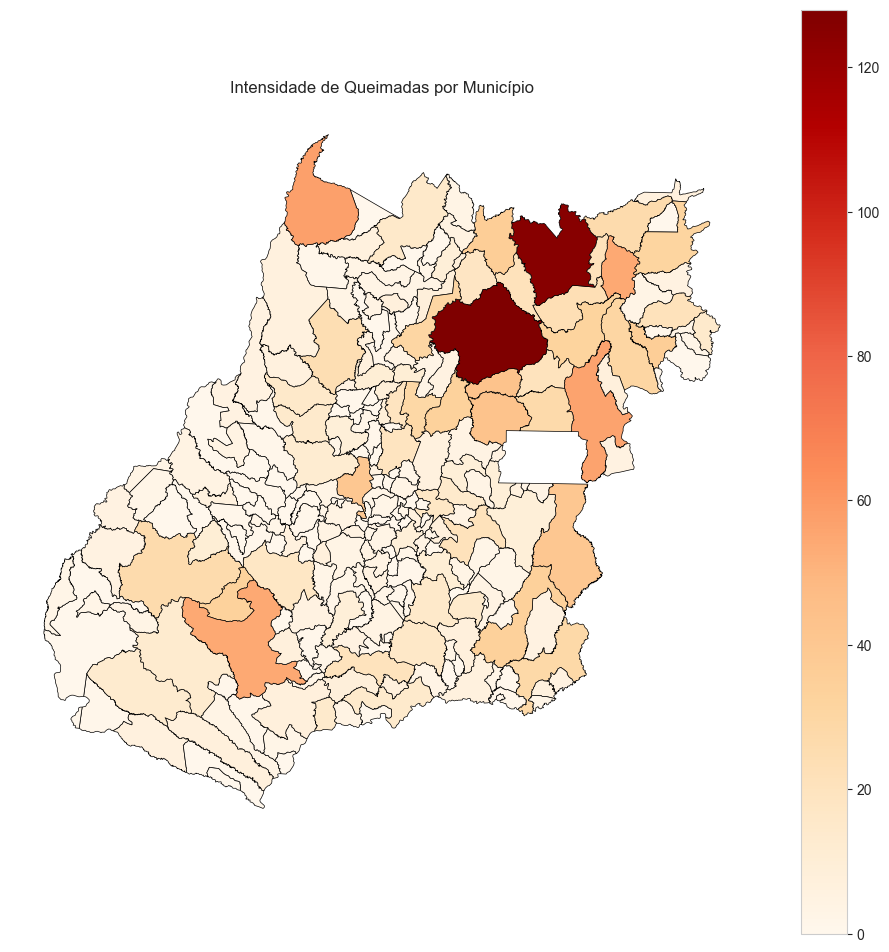

In [9]:
fig, ax = plt.subplots(
    figsize=(12,12)
)

gdf_mapa.plot(
    column="quantidade_focos",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

plt.title(
    "Intensidade de Queimadas por Município"
)

plt.axis("off")

plt.show()

In [10]:
mapa = folium.Map(
    location=[-16, -49],
    zoom_start=6
)

dados_heatmap = (
    gdf_focos[
        ["latitude", "longitude"]
    ]
    .dropna()
    .values
    .tolist()
)

HeatMap(
    dados_heatmap
).add_to(mapa)

mapa